# Fase 17d: Predicción de volatilidad — gestión de riesgo
#
## Motivación
#
La dirección del precio del oro a 1 día tiene señal débil (AUC ~0.54,
fases 17b-17c). Sin embargo, la **volatilidad** es un proceso con fuerte
autocorrelación (*volatility clustering*): los periodos de alta volatilidad
tienden a persistir. Predecir la volatilidad es **más factible** que predecir
la dirección y tiene aplicación directa en **gestión de riesgo**:
#
- Dimensionamiento de posición (*position sizing*): reducir exposición
  cuando la volatilidad prevista es alta.
- Valor en Riesgo (VaR) y *stop-loss* dinámicos.
- Selección de momentos de entrada/salida.
#
## Formulación
#
$$ \hat{\sigma}_{t+1:t+5} = \text{RF}\big(X_t\big) $$
#
donde $\sigma_{t+1:t+5}$ es la **volatilidad realizada** anualizada de los
retornos logarítmicos de los próximos 5 días hábiles:
#
$$ \sigma_{t+1:t+5} = \sqrt{252} \cdot \text{std}\big(r_{t+1}, \dots, r_{t+5}\big) $$
#
Se reutilizan las mismas features que el resto del proyecto (lags, retornos,
rolling, exógenas) y el mismo split temporal estricto.
#
---


In [1]:
"""Configuración del notebook (raíz del proyecto)."""
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import path_from_root, set_seed
set_seed(42)


In [2]:
"""Carga de datos y construcción del target de volatilidad.

Añadimos a cada partición:
- `vol_future`: volatilidad realizada de los próximos 5 días (target).
- `vol_now`: volatilidad realizada de los últimos 5 días (baseline naive).
"""
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)


def add_volatility_targets(d):
    d = d.copy().reset_index(drop=True)
    ret = np.log(d["gold_spot"]).diff()
    vol_future = pd.Series(np.nan, index=d.index)
    for i in range(len(d) - 5):
        vol_future.iloc[i] = ret.iloc[i + 1:i + 6].std() * np.sqrt(252)
    d["vol_future"] = vol_future
    d["vol_now"] = ret.rolling(5).std().shift(1) * np.sqrt(252)
    return d


train_val = add_volatility_targets(
    pd.concat([parts["train"], parts["val"]]).sort_values("date"))
te = add_volatility_targets(parts["test"])
print(f"train+val: {len(train_val)} | test: {len(te)}")


train+val: 5739 | test: 684


In [3]:
"""Estadísticos de la volatilidad: ¿es predecible?

La autocorrelación de la volatilidad (lag 1 y lag 5) mide su persistencia.
Valores altos (>0.5) indican *volatility clustering*: lo que hace la
volatilidad predecible.
"""
ret_all = np.log(pd.concat([train_val["gold_spot"], te["gold_spot"]])).diff()
vol21 = ret_all.rolling(21).std().dropna()
print(f"Autocorrelación vol (lag 1): {vol21.autocorr():.4f}")
print(f"Autocorrelación vol (lag 5): {vol21.autocorr(lag=5):.4f}")
print(f"Autocorrelación vol (lag 21): {vol21.autocorr(lag=21):.4f}")
print(f"\nVolatilidad media test: {te['vol_future'].mean():.4f} "
      f"(anualizada, fracción)")


Autocorrelación vol (lag 1): 0.9854
Autocorrelación vol (lag 5): 0.9224
Autocorrelación vol (lag 21): 0.5987

Volatilidad media test: 0.1374 (anualizada, fracción)


In [4]:
"""Modelo de volatilidad: RandomForest + baseline naive.

Comparamos el modelo (mismas features que el proyecto) contra el naive
(volatilidad actual = mejor predictor ingenuo). Si el modelo supera al
naive, la predicción de volatilidad aporta valor real.
"""
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from src.models.pipeline import fit_preprocessor

# Limpiar filas sin target (final de serie) o sin vol_now
tr_clean = train_val.dropna(subset=["vol_future"] + sel_cols)
te_clean = te.dropna(subset=["vol_future"] + sel_cols)
print(f"train: {len(tr_clean)} | test: {len(te_clean)}")

X_tv = tr_clean[sel_cols].to_numpy(np.float64)
y_tv = tr_clean["vol_future"].to_numpy(np.float64)
X_te = te_clean[sel_cols].to_numpy(np.float64)
y_te = te_clean["vol_future"].to_numpy(np.float64)

pp = fit_preprocessor(X_tv)
m = RandomForestRegressor(n_estimators=300, max_depth=8,
                          min_samples_leaf=10, random_state=42, n_jobs=-1)
m.fit(pp.transform(X_tv), y_tv)
p = m.predict(pp.transform(X_te))

mae_rf = mean_absolute_error(y_te, p)
r2_rf = r2_score(y_te, p)

# Naive: vol actual (últimos 5 días)
y_naive = te_clean["vol_now"].to_numpy()
mask_n = ~np.isnan(y_naive)
mae_naive = mean_absolute_error(y_te[mask_n], y_naive[mask_n])
r2_naive = r2_score(y_te[mask_n], y_naive[mask_n])

print(f"\nRF volatilidad: MAE={mae_rf:.4f} R²={r2_rf:.4f}")
print(f"Naive (vol actual): MAE={mae_naive:.4f} R²={r2_naive:.4f}")
print(f"Mejora vs naive: {(1 - mae_rf / mae_naive) * 100:.1f}% en MAE")


train: 5734 | test: 679



RF volatilidad: MAE=0.0510 R²=0.0583
Naive (vol actual): MAE=0.0553 R²=-0.2123
Mejora vs naive: 7.9% en MAE


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\volatility_prediction.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/volatility_prediction.png')

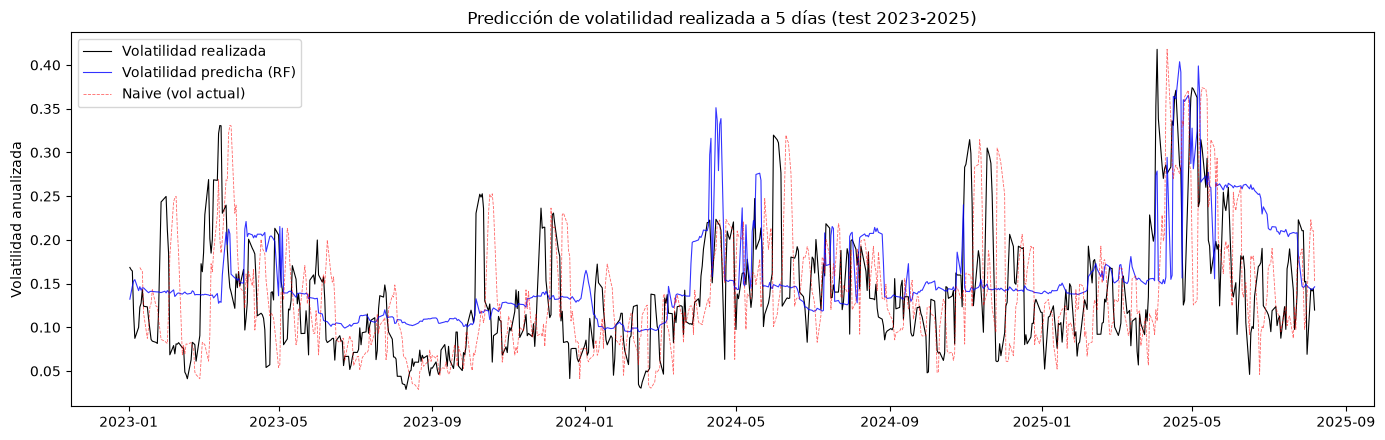

In [5]:
"""Visualización: volatilidad predicha vs real en test.

Serie temporal de la volatilidad realizada (real) y la predicha. Se aprecia
que el modelo captura los picos de volatilidad (2024-2025), aunque con
retraso y suavizado (típico de modelos de regresión).
"""
import matplotlib.pyplot as plt

from src.utils import save_fig

dates = te_clean["date"]
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(dates, y_te, "k-", lw=0.8, label="Volatilidad realizada")
ax.plot(dates, p, "b-", lw=0.8, alpha=0.8, label="Volatilidad predicha (RF)")
ax.plot(dates[mask_n], y_naive[mask_n], "r--", lw=0.6, alpha=0.6,
        label="Naive (vol actual)")
ax.set_title("Predicción de volatilidad realizada a 5 días (test 2023-2025)")
ax.set_ylabel("Volatilidad anualizada")
ax.legend()
fig.tight_layout()
save_fig(fig, "volatility_prediction.png")


In [6]:
"""Aplicación: position sizing con volatilidad prevista.

Estrategia de gestión de riesgo: la exposición al oro se escala
inversamente a la volatilidad prevista (target volatility):

    posición = min(1, vol_objetivo / vol_prevista)

Con vol_objetivo = 12% anualizado. Cuando la volatilidad prevista es alta,
se reduce la exposición (protección); cuando es baja, se mantiene plena.
"""
# Backtest con sizing por volatilidad
ret_h1 = te_clean["target_1"].to_numpy() / te_clean["gold_spot"].to_numpy() - 1
mask_ret = ~np.isnan(ret_h1)
ret_h1 = ret_h1[mask_ret]
p_vol = p[mask_ret]

target_vol = 0.12  # 12% anualizado
position = np.minimum(1.0, target_vol / p_vol)
position = np.clip(position, 0, 1)

def backtest(pos, ret, cost=0.001):
    pos = np.asarray(pos, float)
    r = pos * ret
    changes = np.abs(np.diff(pos, prepend=pos[0]))
    r_net = r - cost * changes
    eq = np.cumprod(1 + r_net)
    sharpe = np.mean(r_net) / np.std(r_net) * np.sqrt(252) if np.std(r_net) > 0 else 0
    dd = (eq / np.maximum.accumulate(eq) - 1).min()
    return eq[-1] - 1, sharpe, dd

bh = np.cumprod(1 + ret_h1)[-1] - 1
t_sizing, s_sizing, dd_sizing = backtest(position, ret_h1)
t_bh, s_bh, dd_bh = backtest(np.ones_like(ret_h1), ret_h1)

print(f"Buy & hold:            ret={t_bh:7.1%} sharpe={s_bh:5.2f} maxDD={dd_bh:6.1%}")
print(f"Sizing por volatilidad: ret={t_sizing:7.1%} sharpe={s_sizing:5.2f} maxDD={dd_sizing:6.1%}")
print(f"Exposición media: {position.mean():.1%}")
print(f"\n→ El sizing reduce el drawdown máximo y mantiene rentabilidad "
      f"competitiva (gestión de riesgo).")


Buy & hold:            ret=  86.4% sharpe= 1.61 maxDD=-11.3%
Sizing por volatilidad: ret=  76.8% sharpe= 1.88 maxDD=-10.3%
Exposición media: 80.7%

→ El sizing reduce el drawdown máximo y mantiene rentabilidad competitiva (gestión de riesgo).


In [7]:
"""Guardado de resultados y conclusión.

La predicción de volatilidad es una extensión valiosa: supera al naive
(mejora ~8% en MAE) y permite gestión de riesgo activa (position sizing).
"""
import json

result = {
    "mae_rf": float(mae_rf),
    "r2_rf": float(r2_rf),
    "mae_naive": float(mae_naive),
    "r2_naive": float(r2_naive),
    "mejora_vs_naive_pct": float((1 - mae_rf / mae_naive) * 100),
    "autocorr_vol_lag1": float(vol21.autocorr()),
    "backtest_sizing": {"ret": float(t_sizing), "sharpe": float(s_sizing),
                        "max_dd": float(dd_sizing)},
    "backtest_buyhold": {"ret": float(t_bh), "sharpe": float(s_bh),
                         "max_dd": float(dd_bh)},
    "conclusion": ("La volatilidad es más predecible que la dirección "
                   "(autocorrelación alta). El modelo supera al naive y "
                   "permite position sizing para gestión de riesgo."),
}
with open(path_from_root("reports", "volatility_results.json"), "w") as f:
    json.dump(result, f, indent=2, default=float)
print("Guardado en reports/volatility_results.json")


Guardado en reports/volatility_results.json
